# Random Forest Regression Model - Hail Size Prediction
## Evelynn Mantia & Izzy Smith 
### Datasets: MRMS MESH & HRRR
#### EAE 583
#### Department of Earth, Atmosphere, and Environment

### **1. Importing Necessary Packages**


In [1]:
!pip install cfgrib
!apt-get install -y libeccodes-dev

Defaulting to user installation because normal site-packages is not writeable
/bin/bash: apt-get: command not found


In [2]:
!pip install herbie-data

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import gzip
import shutil
import xarray as xr
from herbie import Herbie
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import ParameterGrid
import numpy as np
from sklearn.model_selection import PredefinedSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

### **2. Importing MESH data**
#### Grib files were accessed and downloaded from AWS for the following date and time: 07-31-2024, 21Z

In [4]:
gz_path = "MRMS_MESH_Max_60min_00.50_20240731-210000.grib2.gz"
grib_path = "MRMS_MESH_Max_60min_00.50_20240731-210000.grib2"

with gzip.open(gz_path, "rb") as f_in:
    with open(grib_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

# We did not have a lot of experience with grib files, so AI was used to open up these files

In [ ]:
ds_mesh = xr.open_dataset(grib_path, engine="cfgrib") # opening the dataset using xarray
ds_mesh

Ignoring index file 'MRMS_MESH_Max_60min_00.50_20240731-210000.grib2.923a8.idx' older than GRIB file


In [ ]:
ds_mesh = ds_mesh.rename({'unknown':'mesh'}) # MESH is named 'unknown' in the official dataset, so we renamed it 'mesh' for simplification
ds_mesh

### **3. Importing HRRR data**
#### The Herbie package was used to easily access the HRRR environmental variables for our given date/time

In [7]:
H = Herbie("2024-07-31 21:00", model="hrrr", product="sfc", fxx=0) # documentation is available for reference on Herbie user guide

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2024-Jul-31 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


In [8]:
# There are many environmental variables available within the HRRR dataset. For simplification purposes, we chose the variables that we thought would 
# be the most impactful on the production of hail. Using the .inventory method, we were able to determine how each variable was named within the 
# dataset, and create a list, which will later be looped through to access these data.
search = [
    "CAPE:surface",
    "CAPE:90-0 mb above ground",
    "CIN:surface",
    "MXUPHL:5000-2000 m above ground",
    "HLCY:3000-0 m above ground",
    "HGT:level of adiabatic condensation from sfc",
    "REFC:entire atmosphere",
    "TMP:500 mb",
    "TMP:2 m above ground",
    "DPT:2 m above ground",
    "UGRD:10 m above ground",
    "VGRD:10 m above ground",
    "UGRD:700 mb",
    "VGRD:700 mb"
] 

date = ['2024-07-31 21:00'] # this is the chosen date/time for our project, as discussed above with the MESH data accessing

all_ds = [] # creating an empty list to which we can append our data

# The for loop here is looping through all of the HRRR data at our given date/time based on the search list we've defined above, grabbing only those variables. There is a secondary
# empty list/for loop within the original loop to which our data is being appended to. From here, we are merging all of these variables into a singular dataset with xarray. Finally, 
# we are appending that merged dataset to our original empty list above. 
for i in date:
    H = Herbie(i, model="hrrr", product="sfc", fxx=0)

    var_ds = []
    for s in search:
        files = H.download(search=s)
        ds = xr.open_mfdataset(
            files,
            engine="cfgrib",
            backend_kwargs={"indexpath": ""}
        )
        var_ds.append(ds)

    merged = xr.merge(var_ds, compat='override')
    all_ds.append(merged)

ds_hrrr = xr.concat(all_ds, dim='time') # we are concatenating our data with our time dimension; this will be our final HRRR dataset

# The process of importing a singular HRRR variable is extremely simple. However, importing many variables and concatinating them into one dataset
# is extremely complicated. For that reason, AI was also used to import and merge this data.

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2024-Jul-31 21:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


In [9]:
ds_hrrr = ds_hrrr.rename({'unknown':'mxuphl'}) # similarly with MESH, max updraft helicity is named 'unknown' in the offical dataset, so we are renaming it here to 'mxuphl'

In [10]:
ds_hrrr # final hrrr dataset with all of our preferred environmental variables that will be used to train our model

<xarray.Dataset>
Dimensions:                  (time: 1, y: 1059, x: 1799)
Coordinates:
  * time                     (time) datetime64[ns] 2024-07-31T21:00:00
    step                     timedelta64[ns] ...
    surface                  float64 ...
    latitude                 (y, x) float64 dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    longitude                (y, x) float64 dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    valid_time               datetime64[ns] ...
    pressureFromGroundLayer  float64 ...
    heightAboveGroundLayer   float64 ...
    adiabaticCondensation    float64 ...
    atmosphere               float64 ...
    isobaricInhPa            float64 ...
    heightAboveGround        float64 ...
Dimensions without coordinates: y, x
Data variables: (12/13)
    cape                     (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    cin                      (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    mxuphl                   (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    hlcy                     (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    gh                       (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    refc                     (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    ...                       ...
    t2m                      (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    d2m                      (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    u10                      (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    v10                      (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    u                        (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    v                        (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-29T00:26 GRIB to CDM+CF via cfgrib-0.9.1...

### **4. Merging MESH and HRRR datasets**
#### These two datasets already have the same date/time, so we need only need the data points to have the same corresponding longitude and latitude values

In [11]:
print(ds_mesh.time.values)
print(ds_hrrr.time.values)
# this code is for confirmation that we have the correct date/time for both datasets, allowing us to merge the two

2024-07-31T21:00:00.000000000
['2024-07-31T21:00:00.000000000']


In [12]:
# This data is interpolating longitude and latitude values to the closest corresponding data points. 
# We need to interpolate since these are decimal values that are likely not exactly equal.
mesh_on_hrrr = ds_mesh.interp(
    latitude=ds_hrrr.latitude,
    longitude=ds_hrrr.longitude,
    method="linear")

ds_combined = xr.merge([ds_hrrr, mesh_on_hrrr]) # using xarray to merge the datasets into one based on our interpolated lon/lat values

In [13]:
ds_combined # this will be our final dataset that can be input into the random forest regression model; it contains both our HRRR environmental variables, as well as our MESH data

<xarray.Dataset>
Dimensions:                  (time: 1, y: 1059, x: 1799)
Coordinates: (12/13)
  * time                     (time) datetime64[ns] 2024-07-31T21:00:00
    step                     timedelta64[ns] 00:00:00
    surface                  float64 0.0
    latitude                 (y, x) float64 dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    longitude                (y, x) float64 dask.array<chunksize=(1059, 1799), meta=np.ndarray>
    valid_time               datetime64[ns] 2024-07-31T21:00:00
    ...                       ...
    heightAboveGroundLayer   float64 5e+03
    adiabaticCondensation    float64 0.0
    atmosphere               float64 0.0
    isobaricInhPa            float64 500.0
    heightAboveGround        float64 2.0
    heightAboveSea           float64 500.0
Dimensions without coordinates: y, x
Data variables: (12/14)
    cape                     (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    cin                      (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    mxuphl                   (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    hlcy                     (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    gh                       (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    refc                     (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    ...                       ...
    d2m                      (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    u10                      (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    v10                      (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    u                        (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    v                        (time, y, x) float32 dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    mesh                     (y, x) float64 -3.0 -3.0 -3.0 ... -1.0 -1.0 -1.0
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-29T00:26 GRIB to CDM+CF via cfgrib-0.9.1...

### **5. Preprocessing**
#### We need to first standardize the data, and then put them into a tabular dataset, which can be easily accessed later.

In [19]:
# Our data is currently multi-dimensional, so we need to flatten the values for each of the variables (including time, lat, and lon) so they are all 1D arrays
time_flat = ds_combined['time'].values.flatten()
lat_flat = ds_combined['latitude'].values.flatten()
lon_flat = ds_combined['longitude'].values.flatten()
mesh_flat = ds_combined['mesh'].values.flatten()
cape_flat = ds_combined['cape'].values.flatten()
cin_flat = ds_combined['cin'].values.flatten()
mxuphl_flat = ds_combined['mxuphl'].values.flatten()
hlcy_flat = ds_combined['hlcy'].values.flatten()
gh_flat = ds_combined['gh'].values.flatten()
refc_flat = ds_combined['refc'].values.flatten()
t500_flat = ds_combined['t'].values.flatten()
t2m_flat = ds_combined['t2m'].values.flatten()
d2m_flat = ds_combined['d2m'].values.flatten()
u10_flat = ds_combined['u10'].values.flatten()
v10_flat = ds_combined['v10'].values.flatten()
u_flat = ds_combined['u'].values.flatten()
v_flat = ds_combined['v'].values.flatten()

In [20]:
# standardize predictors using standard scalar method (don't need to fit MESH since that is what we're looking to predict)
# machine learning requires standardization of the data points so variables that are of different scales are treated equally within the model
cape_x = preprocessing.StandardScaler().fit_transform(cape_flat.reshape(-1,1))
cin_x = preprocessing.StandardScaler().fit_transform(cin_flat.reshape(-1,1))
mxuphl_x = preprocessing.StandardScaler().fit_transform(mxuphl_flat.reshape(-1,1))
hlcy_x = preprocessing.StandardScaler().fit_transform(hlcy_flat.reshape(-1,1))
gh_x = preprocessing.StandardScaler().fit_transform(gh_flat.reshape(-1,1))
refc_x = preprocessing.StandardScaler().fit_transform(refc_flat.reshape(-1,1))
t500_x = preprocessing.StandardScaler().fit_transform(t500_flat.reshape(-1,1))
t2m_x = preprocessing.StandardScaler().fit_transform(t2m_flat.reshape(-1,1))
d2m_x = preprocessing.StandardScaler().fit_transform(d2m_flat.reshape(-1,1))
u10_x = preprocessing.StandardScaler().fit_transform(u10_flat.reshape(-1,1))
v10_x = preprocessing.StandardScaler().fit_transform(v10_flat.reshape(-1,1))
u_x = preprocessing.StandardScaler().fit_transform(u_flat.reshape(-1,1))
v_x = preprocessing.StandardScaler().fit_transform(v_flat.reshape(-1,1))

In [21]:
# here, we are taking all of our standardized data, flattening it again to ensure the data is 1D, and creating a tabular, pandas data frame to which we can easily index later
df_original = pd.DataFrame({'latitude': lat_flat,
                   'longitude': lon_flat,
                   'MESH': mesh_flat,
                   'CAPE': cape_x.flatten(),
                   'CIN': cin_x.flatten(),
                   'MXUPHL': mxuphl_x.flatten(),
                   'HLCY': hlcy_x.flatten(),
                   'GH': gh_x.flatten(),
                   'REFC': refc_x.flatten(),
                   'T500': t500_x.flatten(),
                   'T2M': t2m_x.flatten(),
                   'D2M': d2m_x.flatten(),
                   'U10': u10_x.flatten(),
                   'V10': v10_x.flatten(),
                   'U': u_x.flatten(),
                   'V': v_x.flatten()})

In [22]:
df = df_original.dropna() # removing any NaNs that may be in the data
df = df[(df['latitude'] >= 43.50) & (df['latitude'] <= 49.38) & (df['longitude'] >= (360-97.24)) & (df['longitude'] <= (360-89.49))] #filtering our data to only include Minnesota
df

,latitude,longitude,MESH,CAPE,CIN,MXUPHL,HLCY,GH,REFC,T500,T2M,D2M,U10,V10,U,V
1287192,43.508441,262.789996,-1.0,3.090155,0.298569,0.0,-0.040376,-0.778904,-0.254089,-1.962466,0.303885,1.172544,-1.131777,1.287244,1.352731,2.085943
1287193,43.508351,262.827048,-1.0,3.145105,0.298569,0.0,0.122293,-0.845293,-0.254089,-1.962466,0.179300,1.203341,-1.068991,1.205585,1.378967,2.070701
1287194,43.508250,262.864100,-1.0,3.186317,0.298569,0.0,0.075816,-0.901649,-0.254089,-1.962466,0.054715,1.218740,-0.880631,1.156590,1.405203,2.070701
1287195,43.508139,262.901152,-1.0,3.158842,0.298569,0.0,-0.063614,-0.905594,-0.254089,-1.928085,0.023568,1.195642,-0.734129,1.140258,1.431439,2.055459
1287196,43.508016,262.938204,-1.0,3.076418,0.298569,0.0,-0.203044,-0.877980,-0.254089,-1.893705,0.065097,1.172544,-0.608556,1.172922,1.470793,2.040217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1697549,49.375809,270.347733,-1.0,1.441661,0.104202,0.0,1.632786,-0.374036,-0.254089,-2.271891,-0.059489,0.541195,0.207669,0.029694,1.588855,-0.520471
1697550,49.373549,270.388233,-1.0,1.482874,0.104202,0.0,1.772216,-0.461164,-0.254089,-2.271891,-0.090635,0.556594,0.123953,-0.035633,1.575737,-0.520471
1697551,49.371278,270.428730,-1.0,1.482874,-0.090164,0.0,1.888408,-0.508842,-0.254089,-2.271891,-0.173692,0.595091,0.061167,-0.100960,1.562619,-0.520471
1697552,49.368995,270.469224,-1.0,1.427924,-0.090164,0.0,1.911646,-0.509857,-0.254089,-2.271891,-0.184074,0.579692,0.040238,-0.133624,1.536383,-0.520471


### **6. Training the Model**
#### The model being used is a Random Forest Regressor; our input data are the environmental HRRR variables, while our output is MESH

In [23]:
y = df['MESH'] # y = output (what we are trying to predict); this will be MESH
X = df.drop(columns=['MESH']) # X = input (what we are using to make our prediction of MESH); this will be everything but MESH
print(len(X), len(y)) # confirming that the number of data points in X = the number of data points in y

44061 44061


In [24]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.1) # splitting off 10% of the original data set to use for our testing dataset
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, train_size=0.8) 
# from what's left of the data after we've removed the testing dataset, separating out the validation and training datasets with 20% and 80% of what's left over respectively

print("# testing samples =", len(X_test))
print("# training samples =", len(X_train))
print("# validation samples =", len(X_val))

# testing samples = 4407
# training samples = 31723
# validation samples = 7931


In [26]:
# here, we are looking to find the best parameters to use for our model
# we can create a parameter grid with different parameters available and later test each of these scenarios to determine the best model
param_grid = {
    "criterion": ['squared_error', 'absolute_error', 'friedman_mse'],
    "max_depth": [4, 6, 8, 12, 20],
    "min_samples_split": [2, 4, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]}

df_params = pd.DataFrame(list(ParameterGrid(param_grid)))
print(df_params.shape)
display(df_params)

(240, 4)


,criterion,max_depth,min_samples_leaf,min_samples_split
0,squared_error,4,1,2
1,squared_error,4,1,4
2,squared_error,4,1,10
3,squared_error,4,1,20
4,squared_error,4,2,2
...,...,...,...,...
235,friedman_mse,20,5,20
236,friedman_mse,20,10,2
237,friedman_mse,20,10,4
238,friedman_mse,20,10,10


In [27]:
# we will use the predefined split approach to separate our training and validation datasets
# we can first concatenate the two subset's X and y values
combined_X = np.concatenate([X_train, X_val])
combined_y = np.concatenate([y_train, y_val])

train_idx = [-1.0] * X_train.shape[0] # turning our training index into an array where each value is equal to -1
val_idx = [0.0] * X_val.shape[0] # turning our validation index into an array where each value is equal to 0

splits = np.concatenate([train_idx, val_idx]) # concatenating these two arrays

splits

array([-1., -1., -1., ...,  0.,  0.,  0.])

In [28]:
ps = PredefinedSplit(splits) # passing our 'splits' array into PredefinedSplit function

# separating training and validation subsets by index based on predefined splits
for i, (train_index, val_index) in enumerate(ps.split()):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Val:  index={val_index}")

Fold 0:
  Train: index=[    0     1     2 ... 31720 31721 31722]
  Val:  index=[31723 31724 31725 ... 39651 39652 39653]


In [25]:
dt = RandomForestRegressor(n_estimators=50, random_state=100) # defining our random forest regression model

# using GridSearchCV to pass our previously defined parameter grid into our random forest regression model
grid = GridSearchCV(
                    estimator=dt, 
                    param_grid=param_grid,
                    scoring='r2',
                    cv=ps, 
                    refit=True, 
                    verbose=1, 
                    return_train_score=True, 
                    n_jobs=-1)

grid.fit(combined_X, combined_y) # testing each set of parameters in our grid with our combined training/validation datasets

print("Best params:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

best_dt = grid.best_estimator_

Fitting 1 folds for each of 240 candidates, totalling 240 fits
Best params: {'criterion': 'squared_error', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV R2: 0.6460804466931174


In [29]:
# now that we've determined the best parameters for our model, we can input these and run our random forest regressor with our training data to train our model
rf = RandomForestRegressor(criterion='squared_error', 
                           max_depth=20, 
                           min_samples_leaf=1, 
                           min_samples_split=2, 
                           n_estimators = 100, 
                           random_state = 100).fit(X=X_train, y=y_train)
rf

RandomForestRegressor(max_depth=20, random_state=100)

### **7. Testing Model Performance**
#### We've trained our model above using the training dataset; now, we can test its ability to successfully predict MESH using our testing dataset

In [30]:
y_pred = rf.predict(X_test) # after training, we can apply the model to our testing dataset to test its true performance

# testing our models R2 score, mean squared error, and mean absolute error
r2 = r2_score(y_test, y_pred)
mean_sq_er = mean_squared_error(y_test, y_pred)
mean_abs_er = mean_absolute_error(y_test, y_pred)

print(f"Test R2 Score: is {r2:.2f}")
print(f"Test Mean Squared Error is {mean_sq_er:.2f}")
print(f"Test Mean Absolute Error is {mean_abs_er:.2f}")

Test R2 Score: is 0.67
Test Mean Squared Error is 0.65
Test Mean Absolute Error is 0.18


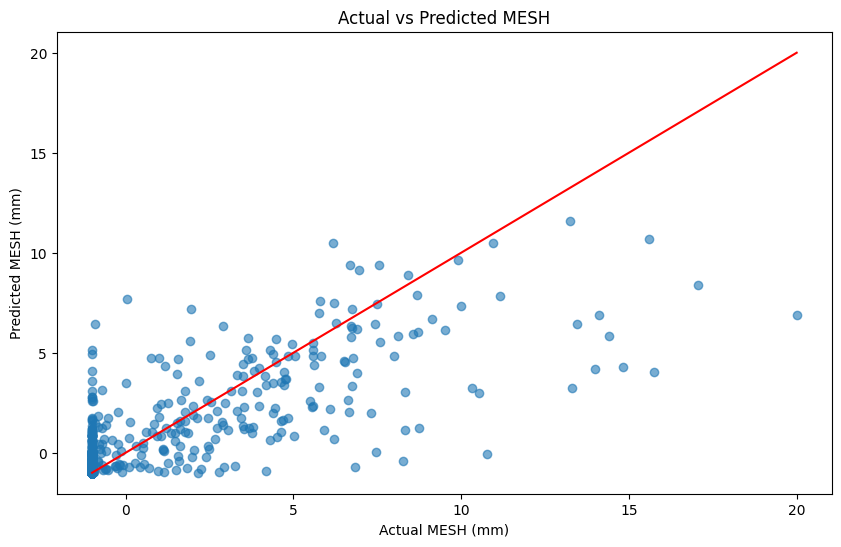

In [32]:
# plotting our actual versus predicted mesh values to further assess the models success and biases
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red') # plotting y=x reference line, where a value on the line would indicate a perfect fit
plt.xlabel('Actual MESH (mm)')
plt.ylabel('Predicted MESH (mm)')
plt.title('Actual vs Predicted MESH')
plt.show()

#### Figure 1. Scatter plot of actual MESH versus predicted MESH in millimeters. This plot shows a comparison of the actual MESH value (x-axis) predicted at a specified latitude/longitude on the defined date/time and the MESH value that the random forest regression model predicted (y-axis). The y=x line is indicated in red to show where these values are equal.